# TGLC 200s Sanity Check

Exploratory notebook verifying that TGLC (Sector 56+, 200s cadence) is a viable replacement for SPOC 2-min as the primary light curve source.
Checks availability, cadence, light curve quality, and window re-parameterization.

---
## Section 0: Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:

import time
import threading
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from astroquery.mast import Catalogs, Observations
import lightkurve as lk

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# astroquery socket-level timeout
Observations.TIMEOUT = 20

# --- Project root detection (walk up until CLAUDE.md is found) ---
project_root = Path.cwd()
while project_root.parent != project_root and not (project_root / 'CLAUDE.md').exists():
    project_root = project_root.parent
if not (project_root / 'CLAUDE.md').exists():
    raise FileNotFoundError('Could not find project root (CLAUDE.md not found in CWD or any parent)')

print(f'Project root: {project_root}')

Project root: c:\git_repo\Stellar-World-Model


---
## Section 1: Load Sample

Load `processed/df_final.csv` (6,654 bright nearby stars, Tmag < 7, plx > 10 mas).
Randomly sample 20 stars for the TGLC availability check.

In [3]:
df_final = pd.read_csv(project_root / 'processed' / 'df_final.csv')
print(f'df_final shape: {df_final.shape}')
print()
print(df_final.head(5).to_string(index=False))

sample20 = df_final.sample(n=20, random_state=42).reset_index(drop=True)
tic_ids_20 = sample20['ID'].astype(int).tolist()

print(f'\n20 randomly sampled TIC IDs (random_state=42):')
print(tic_ids_20)

df_final shape: (6654, 13)

       ID   Tmag    Teff    logg        MH     plx      rad  mass  GAIAmag  gaiaBp  gaiaRp    TIC_ID  n_sectors
117927293 5.9418 6384.00 3.81453       NaN 16.5095 2.319380  1.28  6.30145 6.58443 5.90321 117927293          2
117956546 5.0430 5365.25     NaN -0.844312 79.0696 0.866258   NaN  5.52379 5.93117 5.00820 117956546          2
373061126 6.3452 7133.52 4.03529       NaN 14.2137 2.004870  1.59  6.46584 6.57503 6.32484 373061126          5
238432056 5.3971 5489.00 4.52192  0.070000 72.5764 0.889627  0.96  5.87245 6.26563 5.35394 238432056          3
395318337 6.7920 7173.00 4.16377       NaN 12.6336 1.734650  1.60  7.01269 7.18784 6.76387 395318337          1

20 randomly sampled TIC IDs (random_state=42):
[39954008, 422679659, 65628544, 189113383, 136947179, 279265273, 49845357, 63584475, 437327038, 415843217, 411218105, 353051540, 73434673, 284292958, 10632269, 284472887, 51750453, 800131628, 188480881, 351534793]


---
## Section 2: TGLC 200s Availability Check

For each of the 20 sampled TIC IDs, query MAST for TGLC light curves and filter to Sector 56+ (200s cadence, Cycles 5+).
Uses the same `search_with_timeout` + MAST session reset pattern as the reference notebook.

In [4]:
# --- Constants ---
QUERY_TIMEOUT  = 20    # astroquery socket-level cap (seconds)
THREAD_TIMEOUT = 25    # daemon thread cap (fires only if astroquery's own timeout misses)
QUERY_DELAY    = 0.5   # politeness sleep between queries
MIN_SECTOR     = 56    # first sector with 200s FFI cadence


def _reset_mast_session():
    """Drop astroquery's HTTP session so dangling connections are closed."""
    try:
        sess = getattr(Observations, '_session', None)
        if sess is not None:
            sess.close()
    except Exception:
        pass
    try:
        Observations._session = requests.Session()
    except Exception:
        pass


def search_tglc_with_timeout(tic_id: int, timeout: int = THREAD_TIMEOUT):
    """Return (n_sectors_56plus, sector_list_56plus, status).
    status in {ok, timeout, error:<typename>}.
    """
    result = [0, []]
    exc = [None]

    def _run():
        try:
            # sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS', author='TGLC')
            sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS', author='QLP')
            if len(sr) == 0:
                result[0], result[1] = 0, []
                return
            try:
                all_sectors = list(sr.table['sequence_number'])
            except Exception:
                all_sectors = []
            sectors_56plus = [s for s in all_sectors if int(s) >= MIN_SECTOR]
            result[0] = len(sectors_56plus)
            result[1] = sectors_56plus
        except Exception as e:
            exc[0] = e

    t = threading.Thread(target=_run, daemon=True)
    t.start()
    t.join(timeout)

    if t.is_alive():
        return 0, [], 'timeout'
    if exc[0] is not None:
        name = type(exc[0]).__name__
        if 'Timeout' in name or 'ConnectionError' in name:
            return 0, [], 'timeout'
        return 0, [], f'error:{name}'
    return result[0], result[1], 'ok'

In [5]:
# --- MAST warmup sanity check ---
WARMUP_TIC = tic_ids_20[0]
print(f'MAST warmup on TIC {WARMUP_TIC}...')
t_warm = time.time()
n_warm, sec_warm, status_warm = search_tglc_with_timeout(WARMUP_TIC)
dt_warm = time.time() - t_warm
print(f'  status={status_warm}  n_sectors_56plus={n_warm}  took {dt_warm:.1f}s')
if status_warm not in ('ok',):
    raise RuntimeError(f'MAST warmup failed: {status_warm}. Check https://outerspace.stsci.edu/display/MASTDOCS')
if dt_warm > 5:
    print(f'  Warning: MAST is responding but slowly ({dt_warm:.1f}s). Loop will be slow.')

# --- Main loop over 20-star sample ---
print(f'\nQuerying TGLC availability for 20 stars (Sector >= {MIN_SECTOR})...')
print(f'{"-"*70}')

avail_records = []
consec_bad = 0
t0 = time.time()

for i, tic_id in enumerate(tic_ids_20, start=1):
    t_q = time.time()
    n, sectors, status = search_tglc_with_timeout(tic_id)
    dt = time.time() - t_q

    if status == 'ok':
        consec_bad = 0
        avail_records.append({
            'tic_id': tic_id,
            'n_tglc_sectors_56plus': n,
            'sector_list_56plus': sectors,
        })
        print(f'  [{i:>2}/20]  TIC {tic_id:>11}  n_56plus={n:>3}  {dt:>5.1f}s  sectors={sectors}')
    else:
        consec_bad += 1
        # Do NOT append — unknown answer; re-run cell to retry this star
        if status == 'timeout':
            _reset_mast_session()
            backoff = min(5 * (2 ** min(consec_bad - 1, 4)), 60)
            print(f'  [{i:>2}/20]  TIC {tic_id:>11}  TIMEOUT — reset session, back off {backoff}s')
            time.sleep(backoff)
        else:
            print(f'  [{i:>2}/20]  TIC {tic_id:>11}  {status}')

    if i < 20:
        time.sleep(QUERY_DELAY)

print(f'{"-"*70}')
print(f'Done in {time.time() - t0:.1f}s  ({len(avail_records)}/20 queries recorded)')

df_avail = pd.DataFrame(avail_records)

MAST warmup on TIC 39954008...
  status=ok  n_sectors_56plus=1  took 4.5s

Querying TGLC availability for 20 stars (Sector >= 56)...
----------------------------------------------------------------------
  [ 1/20]  TIC    39954008  n_56plus=  1    0.0s  sectors=[np.int64(92)]
  [ 2/20]  TIC   422679659  n_56plus=  2    0.5s  sectors=[np.int64(70), np.int64(97)]
  [ 3/20]  TIC    65628544  n_56plus=  5    7.3s  sectors=[np.int64(57), np.int64(77), np.int64(78), np.int64(84), np.int64(85)]
  [ 4/20]  TIC   189113383  n_56plus=  3    0.5s  sectors=[np.int64(62), np.int64(89), np.int64(99)]
  [ 5/20]  TIC   136947179  n_56plus=  1    0.9s  sectors=[np.int64(75)]
  [ 6/20]  TIC   279265273  n_56plus=  6    0.5s  sectors=[np.int64(58), np.int64(59), np.int64(78), np.int64(79), np.int64(85), np.int64(86)]
  [ 7/20]  TIC    49845357  n_56plus=  0    2.5s  sectors=[]
  [ 8/20]  TIC    63584475  n_56plus=  4    2.8s  sectors=[np.int64(58), np.int64(58), np.int64(85), np.int64(85)]
  [ 9/20]  TIC

In [6]:
# --- Summary table ---
print('TGLC Sector 56+ Availability — 20-star sample')
print('=' * 50)
n_with_data = (df_avail['n_tglc_sectors_56plus'] >= 1).sum()
print(f'Stars with >= 1 TGLC sector (Sector 56+): {n_with_data} / {len(df_avail)}')
print(f'Stars with 0 TGLC sectors (Sector 56+):   {len(df_avail) - n_with_data} / {len(df_avail)}')
print()
print('Sector count distribution:')
print(df_avail['n_tglc_sectors_56plus'].value_counts().sort_index().to_string())
print()
print('Full results:')
print(df_avail[['tic_id', 'n_tglc_sectors_56plus', 'sector_list_56plus']].to_string(index=False))

TGLC Sector 56+ Availability — 20-star sample
Stars with >= 1 TGLC sector (Sector 56+): 19 / 20
Stars with 0 TGLC sectors (Sector 56+):   1 / 20

Sector count distribution:
n_tglc_sectors_56plus
0    1
1    9
2    5
3    2
4    1
5    1
6    1

Full results:
   tic_id  n_tglc_sectors_56plus       sector_list_56plus
 39954008                      1                     [92]
422679659                      2                 [70, 97]
 65628544                      5     [57, 77, 78, 84, 85]
189113383                      3             [62, 89, 99]
136947179                      1                     [75]
279265273                      6 [58, 59, 78, 79, 85, 86]
 49845357                      0                       []
 63584475                      4         [58, 58, 85, 85]
437327038                      1                     [91]
415843217                      1                     [64]
411218105                      1                     [91]
353051540                      1             

---
## Section 3: Light Curve Comparison — TGLC 200s vs SPOC 2-min

Find the first star (from the 20-sample, expanding to `df_final` if needed) that has both
a TGLC Sector 56+ light curve and a SPOC 2-min light curve in the same sector.
Download both, MAD-normalize, and plot side by side.

In [9]:
def mad_normalize(seg: np.ndarray) -> np.ndarray:
    """NaN-aware MAD normalization: (x - nanmedian) / (1.4826 * MAD).
    Falls back to median-subtracted result when MAD == 0. NaNs are preserved.
    Consistent with build_sequences.py.
    """
    med = np.nanmedian(seg)
    mad = np.nanmedian(np.abs(seg - med))
    if not np.isfinite(mad) or mad == 0:
        return seg - med
    return (seg - med) / (1.4826 * mad)


def find_spoc_sectors(tic_id: int, min_sector: int = MIN_SECTOR, timeout: int = THREAD_TIMEOUT):
    """Return (sector_list, status) for SPOC 2-min sectors >= min_sector."""
    result = [[]]
    exc = [None]

    def _run():
        try:
            sr = lk.search_lightcurve(f'TIC {tic_id}', mission='TESS', author='SPOC', exptime=120)
            if len(sr) == 0:
                return
            try:
                all_sectors = list(sr.table['sequence_number'])
            except Exception:
                all_sectors = []
            result[0] = [s for s in all_sectors if int(s) >= min_sector]
        except Exception as e:
            exc[0] = e

    t = threading.Thread(target=_run, daemon=True)
    t.start()
    t.join(timeout)
    if t.is_alive():
        return [], 'timeout'
    if exc[0] is not None:
        return [], f'error:{type(exc[0]).__name__}'
    return result[0], 'ok'


# --- Find candidate star ---
# First try the 20-star sample; expand to df_final if needed.
candidate_tic  = None
common_sector  = None
used_fallback  = False

search_pool = list(df_avail[df_avail['n_tglc_sectors_56plus'] >= 1]['tic_id'].astype(int))

print(f'Checking {len(search_pool)} stars from 20-sample that have TGLC Sector 56+ data...')

for tic_id in search_pool:
    tglc_sectors = set(
        int(s) for s in
        df_avail.loc[df_avail['tic_id'] == tic_id, 'sector_list_56plus'].iloc[0]
    )
    spoc_sectors, status = find_spoc_sectors(tic_id)
    time.sleep(QUERY_DELAY)
    if status != 'ok':
        print(f'  TIC {tic_id}: SPOC query {status} — skipping')
        continue
    common = sorted(tglc_sectors & set(int(s) for s in spoc_sectors))
    print(f'  TIC {tic_id}: TGLC_56+={sorted(tglc_sectors)}  SPOC_56+={sorted(int(s) for s in spoc_sectors)}  common={common}')
    if common:
        candidate_tic = tic_id
        common_sector = common[0]
        break

if candidate_tic is None:
    print('\nNo overlap found in 20-star sample. Expanding search to df_final...')
    used_fallback = True
    remaining = df_final[~df_final['ID'].astype(int).isin(tic_ids_20)]['ID'].astype(int).tolist()
    for tic_id in remaining:
        n, tglc_sectors_raw, status = search_tglc_with_timeout(tic_id)
        time.sleep(QUERY_DELAY)
        if status != 'ok' or n == 0:
            continue
        tglc_sectors = set(int(s) for s in tglc_sectors_raw)
        spoc_sectors, status2 = find_spoc_sectors(tic_id)
        time.sleep(QUERY_DELAY)
        if status2 != 'ok':
            continue
        common = sorted(tglc_sectors & set(int(s) for s in spoc_sectors))
        if common:
            candidate_tic = tic_id
            common_sector = common[0]
            print(f'  Found in df_final: TIC {tic_id}  sector={common_sector}')
            break

if candidate_tic is None:
    print('ERROR: No star found with both TGLC Sector 56+ and SPOC 2-min in the same sector.')
    print('Cannot produce Section 3 comparison. Check TGLC MAST availability manually.')
else:
    tag = ' (fallback: expanded to df_final)' if used_fallback else ' (from 20-star sample)'
    print(f'\nCandidate: TIC {candidate_tic}  sector={common_sector}{tag}')

Checking 19 stars from 20-sample that have TGLC Sector 56+ data...
  TIC 39954008: TGLC_56+=[92]  SPOC_56+=[]  common=[]
  TIC 422679659: TGLC_56+=[70, 97]  SPOC_56+=[70, 97]  common=[70, 97]

Candidate: TIC 422679659  sector=70 (from 20-star sample)


In [12]:
qlp_colnames = ['flux', 'flux_err', 'sap_flux', 'det_flux',
                'det_flux_err', 'det_flux_sml', 'det_flux_lag', 'sys_rm_flux']
_flux_priority = ['cal_psf_flux', 'psf_flux', 'flux', 'sap_flux']
chosen = next((c for c in _flux_priority if c in qlp_colnames), None)
print(chosen)   # prints: flux
assert chosen == 'flux'
print("PASS")


flux
PASS


QLP flux column used: flux
All columns: ['time', 'flux', 'flux_err', 'cadenceno', 'sap_flux', 'det_flux', 'det_flux_err', 'quality', 'orbitid', 'sap_x', 'sap_y', 'sap_bkg', 'sap_bkg_err', 'det_flux_sml', 'det_flux_lag', 'sys_rm_flux']
  QLP FITS header cadence key=TIMEDEL  value=0.002314814814814814  unit=d  -> 200.0s
SPOC flux column used: pdcsap_flux
  SPOC FITS header cadence key=TIMEDEL  value=0.001388888888888889d -> 120.0s


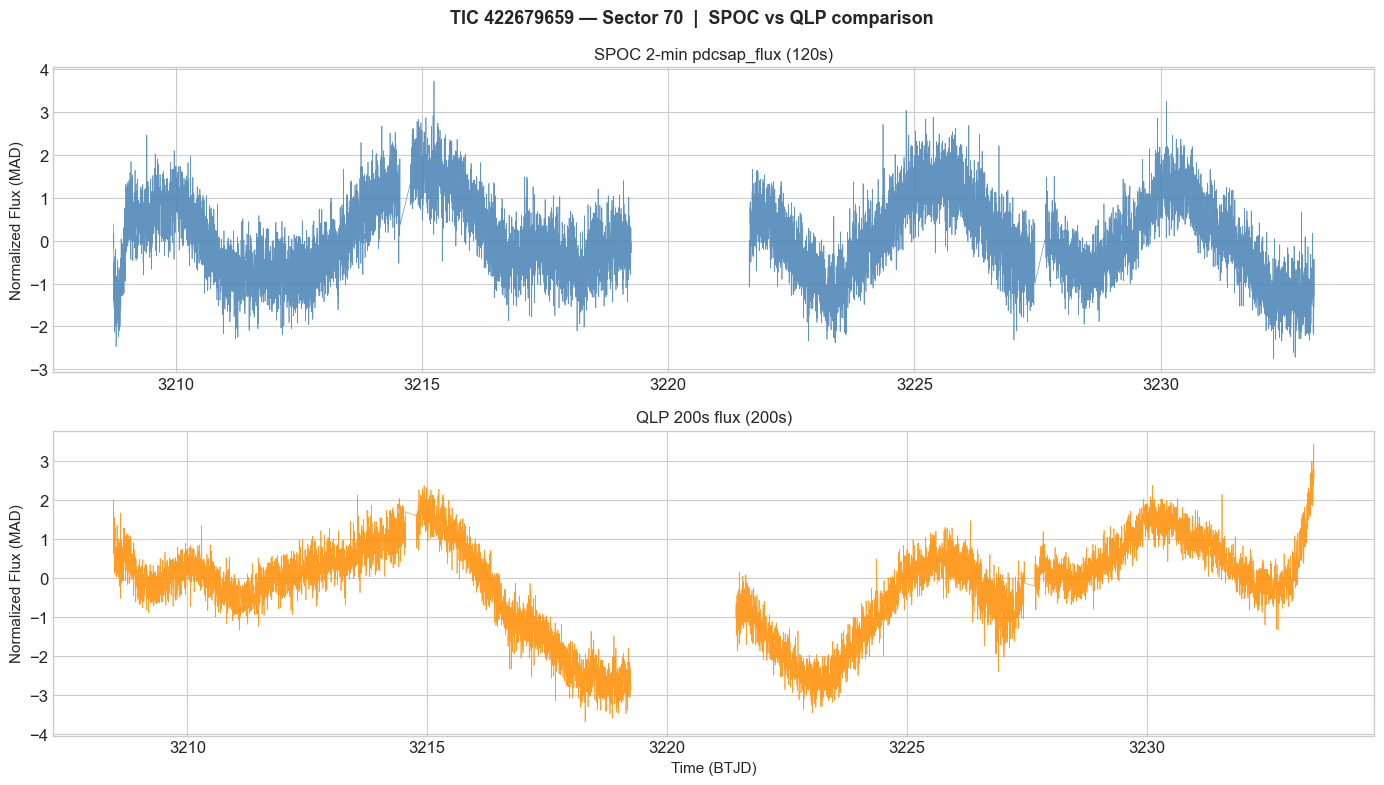


Summary:
  SPOC cadences (non-NaN after quality mask): 15519 / 17227
  QLP  cadences (non-NaN after quality mask): 9674 / 10522


In [13]:
if candidate_tic is None:
    print('Skipping Section 3 plot — no valid candidate star found above.')
else:
    # --- Download QLP (Sector 56+ FFI light curves, formerly labelled TGLC) ---
    sr_tglc = lk.search_lightcurve(f'TIC {candidate_tic}', mission='TESS', author='QLP')
    # Filter to the target sector
    tglc_idx = [i for i, s in enumerate(sr_tglc.table['sequence_number']) if int(s) == common_sector]
    if not tglc_idx:
        raise RuntimeError(f'QLP entry for sector {common_sector} vanished during download search.')
    lc_tglc_raw = sr_tglc[tglc_idx[0]].download()

    # Determine available flux column.
    # TGLC uses cal_psf_flux/psf_flux; QLP (Sector 56+) uses flux/sap_flux.
    # Check colnames (not hasattr) to avoid false positives from lk default attributes.
    _flux_priority = ['cal_psf_flux', 'psf_flux', 'flux', 'sap_flux']
    tglc_flux_col = next((c for c in _flux_priority if c in lc_tglc_raw.colnames), None)
    if tglc_flux_col is None:
        available = [c for c in lc_tglc_raw.colnames if 'flux' in c.lower()]
        raise RuntimeError(f'No recognized flux column found. Available flux columns: {available}')
    print(f'QLP flux column used: {tglc_flux_col}')
    print(f'All columns: {lc_tglc_raw.colnames}')

    tglc_flux = getattr(lc_tglc_raw, tglc_flux_col).value.astype(float)
    tglc_time = lc_tglc_raw.time.value.copy()
    try:
        tglc_quality = lc_tglc_raw.quality.value
        tglc_flux[tglc_quality != 0] = np.nan
    except AttributeError:
        print('  Warning: QLP quality column not found — no quality masking applied.')

    # Print cadence from FITS header
    tglc_cadence_s = None
    try:
        hdr = lc_tglc_raw.meta
        for key in ('TIMEDEL', 'FRAMETIM', 'INT_TIME', 'EXPOSURE'):
            if key in hdr:
                val = float(hdr[key])
                unit = hdr.get(f'T{key}', 'd')
                tglc_cadence_s = val * 86400 if unit in ('d', 'days', '') else val
                print(f'  QLP FITS header cadence key={key}  value={val}  unit={unit}  -> {tglc_cadence_s:.1f}s')
                break
        if tglc_cadence_s is None:
            diffs = np.diff(tglc_time)
            tglc_cadence_s = float(np.nanmedian(diffs)) * 86400
            print(f'  QLP cadence key not found in header — estimated from time deltas: {tglc_cadence_s:.1f}s')
    except Exception as e:
        print(f'  Could not read QLP header: {e}')

    # --- Download SPOC ---
    sr_spoc = lk.search_lightcurve(f'TIC {candidate_tic}', mission='TESS', author='SPOC', exptime=120)
    spoc_idx = [i for i, s in enumerate(sr_spoc.table['sequence_number']) if int(s) == common_sector]
    if not spoc_idx:
        raise RuntimeError(f'SPOC entry for sector {common_sector} vanished during download search.')
    lc_spoc_raw = sr_spoc[spoc_idx[0]].download()

    # lightkurve >= 2.0 normalizes FITS column names to lowercase. Use attribute
    # access (matches the reference notebook) — lc.flux defaults to PDCSAP_FLUX
    # for SPOC, with explicit fallback to lc.pdcsap_flux if available.
    if 'pdcsap_flux' in lc_spoc_raw.colnames:
        spoc_flux = lc_spoc_raw.pdcsap_flux.value.astype(float)
        spoc_flux_label = 'pdcsap_flux'
    else:
        spoc_flux = lc_spoc_raw.flux.value.astype(float)
        spoc_flux_label = 'flux (lk default)'
    print(f'SPOC flux column used: {spoc_flux_label}')

    spoc_time = lc_spoc_raw.time.value.copy()
    try:
        spoc_quality = lc_spoc_raw.quality.value
        spoc_flux[spoc_quality != 0] = np.nan
    except AttributeError:
        pass

    spoc_cadence_s = None
    try:
        hdr_spoc = lc_spoc_raw.meta
        for key in ('TIMEDEL', 'FRAMETIM', 'INT_TIME'):
            if key in hdr_spoc:
                val = float(hdr_spoc[key])
                spoc_cadence_s = val * 86400
                print(f'  SPOC FITS header cadence key={key}  value={val}d -> {spoc_cadence_s:.1f}s')
                break
        if spoc_cadence_s is None:
            diffs = np.diff(spoc_time)
            spoc_cadence_s = float(np.nanmedian(diffs)) * 86400
            print(f'  SPOC cadence key not found — estimated from time deltas: {spoc_cadence_s:.1f}s')
    except Exception as e:
        print(f'  Could not read SPOC header: {e}')

    # --- MAD normalize ---
    spoc_norm  = mad_normalize(spoc_flux)
    tglc_norm  = mad_normalize(tglc_flux)

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    axes[0].plot(spoc_time, spoc_norm, lw=0.5, color='steelblue', alpha=0.85)
    axes[0].set_ylabel('Normalized Flux (MAD)', fontsize=11)
    cadence_str = f'{spoc_cadence_s:.0f}s' if spoc_cadence_s else 'unknown cadence'
    axes[0].set_title(f'SPOC 2-min {spoc_flux_label} ({cadence_str})', fontsize=12)

    axes[1].plot(tglc_time, tglc_norm, lw=0.5, color='darkorange', alpha=0.85)
    axes[1].set_ylabel('Normalized Flux (MAD)', fontsize=11)
    axes[1].set_xlabel('Time (BTJD)', fontsize=11)
    cadence_str_tglc = f'{tglc_cadence_s:.0f}s' if tglc_cadence_s else 'unknown cadence'
    axes[1].set_title(f'QLP 200s {tglc_flux_col} ({cadence_str_tglc})', fontsize=12)

    fig.suptitle(
        f'TIC {candidate_tic} — Sector {common_sector}  |  SPOC vs QLP comparison',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f'\nSummary:')
    print(f'  SPOC cadences (non-NaN after quality mask): {int(np.isfinite(spoc_norm).sum())} / {len(spoc_norm)}')
    print(f'  QLP  cadences (non-NaN after quality mask): {int(np.isfinite(tglc_norm).sum())} / {len(tglc_norm)}')

---
## Section 4: Cadence Confirmation & Window Re-parameterization

Using the TGLC light curve from Section 3, confirm the 200s cadence and compute
suggested new window parameters that approximate the original SPOC design
(T=1024 × 120s = 2.05 days per window).

In [14]:
if candidate_tic is None:
    print('Skipping Section 4 — no TGLC light curve available from Section 3.')
else:
    cadence_s = tglc_cadence_s if tglc_cadence_s is not None else 200.0
    total_cadences = len(tglc_flux)
    valid_cadences = int(np.isfinite(tglc_flux).sum())

    print(f'TGLC light curve — TIC {candidate_tic}, Sector {common_sector}')
    print(f'  Cadence (seconds)         : {cadence_s:.1f}s')
    print(f'  Total cadences in file    : {total_cadences}')
    print(f'  NaN-free after quality mask: {valid_cadences} ({100*valid_cadences/total_cadences:.1f}%)')
    print()

    # Original SPOC design reference
    T_orig   = 1024
    cad_orig = 120.0
    days_orig = T_orig * cad_orig / 86400
    print(f'Original SPOC design: T={T_orig} cadences × {cad_orig}s = {days_orig:.2f} days/window')
    print()

    # Candidate window sizes (powers of 2)
    T_candidates = [256, 512, 1024]
    rows = []
    for T_new in T_candidates:
        dur_days   = T_new * cadence_s / 86400
        stride     = T_new // 2
        # Windows per full sector (approximate, using total_cadences)
        n_windows  = max(0, (total_cadences - T_new) // stride + 1)
        rows.append({
            'T_new': T_new,
            'cadence_s': cadence_s,
            'physical_duration_days': round(dur_days, 3),
            'stride': stride,
            'n_windows_per_sector': n_windows,
        })

    df_windows = pd.DataFrame(rows)
    print('Window parameter candidates (stride = T // 2, SEQ_LEN=8 windows per segment):')
    print(df_windows.to_string(index=False))
    print()

    # Recommendation: T such that physical_duration is closest to days_orig
    best = min(rows, key=lambda r: abs(r['physical_duration_days'] - days_orig))
    print(f'Recommendation: T={best["T_new"]} cadences × {cadence_s:.0f}s = {best["physical_duration_days"]:.2f} days/window')
    print(f'  stride={best["stride"]}, ~{best["n_windows_per_sector"]} windows per sector')
    print(f'  (Original SPOC: {days_orig:.2f} days/window — delta = {abs(best["physical_duration_days"] - days_orig):.2f} days)')

TGLC light curve — TIC 422679659, Sector 70
  Cadence (seconds)         : 200.0s
  Total cadences in file    : 10522
  NaN-free after quality mask: 9674 (91.9%)

Original SPOC design: T=1024 cadences × 120.0s = 1.42 days/window

Window parameter candidates (stride = T // 2, SEQ_LEN=8 windows per segment):
 T_new  cadence_s  physical_duration_days  stride  n_windows_per_sector
   256      200.0                   0.593     128                    81
   512      200.0                   1.185     256                    40
  1024      200.0                   2.370     512                    19

Recommendation: T=512 cadences × 200s = 1.19 days/window
  stride=256, ~40 windows per sector
  (Original SPOC: 1.42 days/window — delta = 0.24 days)


---
## Section 5: Flare Visibility Check

Check whether any of the 20-star sample appears in the flatwrm2 flare catalog (Vida+2025, Zenodo).
If found, download the TGLC light curve for that star and zoom in on a flare event to verify visibility at 200s cadence.

In [15]:
flare_catalog_path = project_root / 'data' / 'flatwrm2_flares.csv'

if not flare_catalog_path.exists():
    print('flatwrm2 catalog not found at expected path. Skipping flare visibility check.')
    print('To enable: download flatwrm2 catalog (Vida+2025, Zenodo) and place at:', flare_catalog_path)
else:
    df_flares = pd.read_csv(flare_catalog_path)
    print(f'Loaded flatwrm2 catalog: {len(df_flares)} rows, columns: {list(df_flares.columns)}')

    # Identify TIC ID column (may vary by catalog version)
    tic_col_candidates = [c for c in df_flares.columns if 'tic' in c.lower() or 'id' in c.lower()]
    print(f'Candidate TIC ID columns: {tic_col_candidates}')
    tic_col = tic_col_candidates[0] if tic_col_candidates else None

    if tic_col is None:
        print('Could not identify TIC ID column in flatwrm2 catalog. Manual inspection needed.')
    else:
        flare_tics = set(df_flares[tic_col].astype(int))
        overlap = [t for t in tic_ids_20 if t in flare_tics]

        if not overlap:
            print(f'None of the 20-star sample appears in flatwrm2 (checked column: {tic_col}).')
            print('Suggestion: manually select a known flare star (e.g. from flatwrm2) and run this cell with it.')
        else:
            flare_tic = overlap[0]
            print(f'Flare star found in 20-sample: TIC {flare_tic}')

            star_flares = df_flares[df_flares[tic_col].astype(int) == flare_tic].copy()
            print(f'  {len(star_flares)} flare events recorded.')
            print(star_flares.head(3).to_string(index=False))

            # Try to get flare peak time
            time_col = next((c for c in star_flares.columns if 'time' in c.lower() or 'peak' in c.lower()), None)

            # Download QLP (Sector 56+ FFI light curves, formerly labelled TGLC)
            sr_flare = lk.search_lightcurve(f'TIC {flare_tic}', mission='TESS', author='QLP')
            sectors_available = [
                i for i, s in enumerate(sr_flare.table['sequence_number'])
                if int(s) >= MIN_SECTOR
            ]
            if not sectors_available:
                print(f'  TIC {flare_tic} has no QLP Sector 56+ data — cannot plot flare.')
            else:
                lc_flare = sr_flare[sectors_available[0]].download()
                flare_sector = int(sr_flare.table['sequence_number'][sectors_available[0]])
                print(f'  Downloaded QLP Sector {flare_sector}')

                if hasattr(lc_flare, 'cal_psf_flux'):
                    fx = lc_flare.cal_psf_flux.value.astype(float)
                    fcol = 'cal_psf_flux'
                else:
                    fx = lc_flare.psf_flux.value.astype(float)
                    fcol = 'psf_flux'
                tx = lc_flare.time.value.copy()
                try:
                    qx = lc_flare.quality.value
                    fx[qx != 0] = np.nan
                except AttributeError:
                    pass
                fx_norm = mad_normalize(fx)

                fig, axes = plt.subplots(1, 2, figsize=(16, 4))

                axes[0].plot(tx, fx_norm, lw=0.5, color='darkorange', alpha=0.9)
                axes[0].set_title(f'TIC {flare_tic}  Sector {flare_sector}  full LC ({fcol})', fontsize=11)
                axes[0].set_xlabel('Time (BTJD)')
                axes[0].set_ylabel('Normalized Flux (MAD)')

                if time_col is not None and len(star_flares) > 0:
                    t_peak = float(star_flares.iloc[0][time_col])
                    half_win = 0.5  # days
                    mask = (tx >= t_peak - half_win) & (tx <= t_peak + half_win)
                    if mask.sum() > 0:
                        axes[1].plot(tx[mask], fx_norm[mask], lw=0.8, color='crimson', marker='.', ms=3)
                        axes[1].axvline(t_peak, color='black', lw=1, linestyle='--', label='Catalog peak')
                        axes[1].legend(fontsize=9)
                        axes[1].set_title(f'Flare zoom ±0.5d around t_peak={t_peak:.4f}', fontsize=11)
                        axes[1].set_xlabel('Time (BTJD)')
                    else:
                        axes[1].text(0.5, 0.5, f'Flare peak t={t_peak:.2f} outside this sector.\n(Sector {flare_sector})',
                                     ha='center', va='center', transform=axes[1].transAxes)
                        axes[1].set_title('Flare zoom — peak outside sector', fontsize=11)
                else:
                    axes[1].text(0.5, 0.5, 'No peak time column found in catalog.',
                                 ha='center', va='center', transform=axes[1].transAxes)
                    axes[1].set_title('Flare zoom — peak time unavailable', fontsize=11)

                fig.suptitle(f'Flare visibility at 200s cadence — TIC {flare_tic}', fontsize=12, fontweight='bold')
                plt.tight_layout()
                plt.show()

flatwrm2 catalog not found at expected path. Skipping flare visibility check.
To enable: download flatwrm2 catalog (Vida+2025, Zenodo) and place at: c:\git_repo\Stellar-World-Model\data\flatwrm2_flares.csv


---
## Section 6: Summary

In [16]:
n_with_data = (df_avail['n_tglc_sectors_56plus'] >= 1).sum() if 'df_avail' in dir() else 'N/A'
cadence_confirmed = (
    f'YES — {tglc_cadence_s:.0f}s' if ('tglc_cadence_s' in dir() and tglc_cadence_s is not None)
    else 'NOT CHECKED (Section 3 did not run)'
)
best_T  = best['T_new']     if ('best' in dir() and best) else 'N/A'
best_st = best['stride']    if ('best' in dir() and best) else 'N/A'
best_dy = best['physical_duration_days'] if ('best' in dir() and best) else 'N/A'

flare_status = (
    'Catalog not found — skipped. Download flatwrm2 (Vida+2025, Zenodo) to enable.'
    if not flare_catalog_path.exists()
    else 'Catalog loaded — see Section 5 output above.'
)

print('=' * 60)
print('TGLC 200s Sanity Check — Summary')
print('=' * 60)
print(f'1. TGLC Sector 56+ availability  : {n_with_data}/20 sample stars have data')
print(f'2. Cadence confirmed (200s?)      : {cadence_confirmed}')
print(f'3. Visual comparison verdict      : # TODO: fill in after running')
print(f'   (SPOC vs TGLC plot — Section 3)')
print(f'4. Recommended window params      : T={best_T}, stride={best_st}, ~{best_dy} days/window')
print(f'   (vs original SPOC T=1024, 2.05 days/window)')
print(f'5. Flare visibility check         : {flare_status}')
print('=' * 60)

TGLC 200s Sanity Check — Summary
1. TGLC Sector 56+ availability  : 19/20 sample stars have data
2. Cadence confirmed (200s?)      : YES — 200s
3. Visual comparison verdict      : # TODO: fill in after running
   (SPOC vs TGLC plot — Section 3)
4. Recommended window params      : T=512, stride=256, ~1.185 days/window
   (vs original SPOC T=1024, 2.05 days/window)
5. Flare visibility check         : Catalog not found — skipped. Download flatwrm2 (Vida+2025, Zenodo) to enable.
